# Federated LASSO — Aggregating the Per-Study Vectors

**Coordinator notebook in the federated architecture.**

The four `Lasso_<STUDY>` notebooks each fit `LassoCV` on one study alone and
wrote a coefficient vector to `vectors/`. This notebook is the coordinator: it
combines them into a federated sparse model **without touching any study's
subject-level data**.

Three aggregation rules:

1. **Median + IQR** — coordinate-wise median across sites, IQR as spread. The
   simple federated-LASSO rule; a feature kept if selected by a majority of
   sites. Robust but can zero out features the sites disagree on.
2. **FedAvg-by-N** — sample-size-weighted mean of the per-site coefficients.
3. **ADMM consensus** — the sites iterate to agreement on a single sparse
   vector that solves the joint LASSO. Only the consensus vector crosses the
   wire each round; subject data never moves. ADMM recovers the centralised
   LASSO solution that median/FedAvg only approximate.

## Cohorts evaluated
- **Panel A** — 4 studies, 9 features.
- **Panel B** — 3 studies, 12 features.
- **Panel B excluding SDY1737** — the deck's headline cohort (SDY524 + SDY569),
  where the federated model keeps weight_kg, GAD65 (negative — the expected
  immune-destruction sign), treatment, and Sex.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from scipy.stats import f as fdist, ncf

import oadr_data as od

RNG_SEED = 42
N_FOLDS = 5
ALPHA_STAT = 0.05
ALPHA_LASSO = {"A": 0.02, "B": 0.008}     # L1 penalty per panel (Panel B matches the deck)
np.random.seed(RNG_SEED)
(REPO / "results").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)

PANEL_A_FEATS = ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']
PANEL_B_FEATS = ['Sex', 'age_years', 'disease_duration_years', 'bmi', 'height_cm', 'weight_kg', 'GAD65', 'IA2IC', 'MIAA', 'ZNT8', 'ICA', 'received_active_treatment']
PANEL_A_STUDIES = ["SDY524", "SDY569", "SDY797", "SDY1737"]
PANEL_B_STUDIES = ["SDY524", "SDY569", "SDY1737"]
print("Repo root:", REPO)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


## 2. Read the per-study vectors and show consensus selection

Each `vectors/<STUDY>_lasso_panel<X>_vector.csv` holds one study's LASSO
vector and a `selected` flag per feature. We stack them and report, per
feature, the median coefficient, the IQR, and how many sites selected it.


In [2]:
def read_lasso_vectors(panel, studies, feats):
    coefs, sel, sizes, names = [], [], [], []
    for s in studies:
        p = REPO / "vectors" / f"{s}_lasso_panel{panel}_vector.csv"
        if not p.exists():
            continue
        df = pd.read_csv(p).set_index("feature")
        coefs.append(df.loc[feats, "coefficient"].values.astype(float))
        sel.append(df.loc[feats, "selected"].values.astype(int))
        sizes.append(int(df.loc[feats[0], "n_subjects"]))
        names.append(s)
    return np.array(coefs), np.array(sel), np.array(sizes), names

def consensus_table(panel, studies, feats):
    coefs, sel, sizes, names = read_lasso_vectors(panel, studies, feats)
    tbl = pd.DataFrame(coefs.T, index=feats, columns=names)
    tbl["median"] = np.median(coefs, axis=0)
    tbl["IQR"] = np.percentile(coefs, 75, axis=0) - np.percentile(coefs, 25, axis=0)
    tbl["FedAvg_by_N"] = np.average(coefs, axis=0, weights=sizes)
    tbl["n_sites_selected"] = sel.sum(axis=0)
    return tbl, names

print("=== Panel A consensus ===")
tblA, namesA = consensus_table("A", PANEL_A_STUDIES, PANEL_A_FEATS)
print(tblA.round(3).to_string())
tblA.to_csv("vectors/federated_lasso_panelA_consensus.csv")
print()
print("=== Panel B consensus ===")
tblB, namesB = consensus_table("B", PANEL_B_STUDIES, PANEL_B_FEATS)
print(tblB.round(3).to_string())
tblB.to_csv("vectors/federated_lasso_panelB_consensus.csv")


=== Panel A consensus ===
       SDY524  SDY569  SDY797  SDY1737  median    IQR  FedAvg_by_N  n_sites_selected
MIAA    0.049   0.000   0.000      0.0   0.000  0.012        0.025                 1
GAD65  -0.276  -0.000   0.000      0.0   0.000  0.069       -0.138                 1
IA2IC  -0.099   0.000   0.178      0.0   0.000  0.069        0.009                 2
ICA     0.000   0.000  -0.120      0.0   0.000  0.030       -0.039                 1
ZNT8    0.136   0.000   0.000      0.0   0.000  0.034        0.068                 1
8-12   -0.257  -0.687   0.000      0.0  -0.129  0.365       -0.174                 2
13-17  -0.000   0.000   0.000      0.0   0.000  0.000        0.000                 0
>18     0.031   0.000   0.000      0.0   0.000  0.008        0.016                 1
Sex     0.133  -0.000   0.141      0.0   0.067  0.135        0.113                 2

=== Panel B consensus ===
                           SDY524  SDY569  SDY1737  median    IQR  FedAvg_by_N  n_sites_selected


## 3. ADMM consensus LASSO

ADMM (Boyd et al. 2011, §8.2) solves the joint LASSO across institutions by
iterating: each site does a local update on its **own** data, the coordinator
soft-thresholds the average to enforce sparsity and broadcasts the consensus
vector, sites update their dual variables. Only the consensus vector `z` (and
each site's local `β_k`, `u_k`) crosses the wire — subject rows never move. We
use an adaptive penalty `ρ` for stability when sites differ in size.


In [3]:
def soft_threshold(v, lam):
    return np.sign(v) * np.maximum(np.abs(v) - lam, 0.0)

def admm_lasso(X_list, y_list, alpha, rho_init=1.0, max_iter=10000, tol=1e-7,
               adaptive_rho=True, mu=10.0, tau=2.0):
    """Consensus ADMM-Lasso with intercept column. X_list already scaled per site."""
    K = len(X_list)
    Xa_list = [np.column_stack([np.ones(len(X)), X]) for X in X_list]
    p = Xa_list[0].shape[1]
    N = sum(len(y) for y in y_list)
    betas = [np.zeros(p) for _ in range(K)]
    us = [np.zeros(p) for _ in range(K)]
    z = np.zeros(p); rho = rho_init
    Xty = [(1.0 / N) * (Xa.T @ y) for Xa, y in zip(Xa_list, y_list)]
    XtX = [(1.0 / N) * (Xa.T @ Xa) for Xa in Xa_list]
    def inv(r): return [np.linalg.inv(XtX[k] + r * np.eye(p)) for k in range(K)]
    A_inv = inv(rho)
    for t in range(max_iter):
        for k in range(K):
            betas[k] = A_inv[k] @ (Xty[k] + rho * (z - us[k]))
        mean_term = np.mean([betas[k] + us[k] for k in range(K)], axis=0)
        z_new = mean_term.copy()
        z_new[1:] = soft_threshold(mean_term[1:], alpha / (rho * K))
        for k in range(K):
            us[k] = us[k] + betas[k] - z_new
        primal = np.sqrt(np.mean([np.sum((betas[k] - z_new) ** 2) for k in range(K)]))
        dual = rho * np.linalg.norm(z_new - z)
        z = z_new
        if primal < tol and dual < tol:
            return z[0], z[1:], t + 1
        if adaptive_rho and (t + 1) % 20 == 0:
            if primal > mu * dual:
                rho *= tau; [us[k].__imul__(1 / tau) for k in range(K)]; A_inv = inv(rho)
            elif dual > mu * primal:
                rho /= tau; [us[k].__imul__(tau) for k in range(K)]; A_inv = inv(rho)
    return z[0], z[1:], max_iter


## 4. Honest federated cross-validation

For each panel and each rule (Median, FedAvg-by-N, ADMM, plus Solo), a
federated CV: every study splits its **own** rows; in each fold the sites fit
locally (MinMaxScaler per site), the vectors/updates are aggregated, every
study predicts its **own** held-out rows, and each study reports only summary
scalars (RSS, Σy, Σy², n). The coordinator combines those into global MSE / R²
/ power. Nothing subject-level is pooled.


In [4]:
def calc_power(n, k, f2, alpha=ALPHA_STAT):
    if n <= k + 1 or f2 <= 0:
        return float("nan")
    F_crit = fdist.ppf(1 - alpha, k, n - k - 1)
    return float(1 - ncf.cdf(F_crit, k, n - k - 1, f2 * n))

def f2_from_r2(r2):
    return r2 / (1 - r2) if 0 < r2 < 1 else 0.0

def study_summary(y, pred):
    m = ~np.isnan(pred); yy, pp = y[m], pred[m]
    return {"rss": float(np.sum((yy - pp) ** 2)), "sum_y": float(np.sum(yy)),
            "sum_y2": float(np.sum(yy ** 2)), "n": int(m.sum())}

def score_from_summaries(summaries, k):
    N = sum(d["n"] for d in summaries); RSS = sum(d["rss"] for d in summaries)
    SY = sum(d["sum_y"] for d in summaries); SY2 = sum(d["sum_y2"] for d in summaries)
    gmean = SY / N; TSS = SY2 - N * gmean ** 2
    mse = RSS / N; r2 = 1 - RSS / TSS if TSS > 0 else float("nan")
    return mse, r2, N, calc_power(N, k, f2_from_r2(r2))

def load_study(panel, study, feats):
    if panel == "A":
        a = od.load_panel_a(study)
        return a[feats].values.astype(float), a[od.PANEL_A_TARGET].values.astype(float)
    b = od.load_panel_b(study)
    for col in ("bmi", "height_cm", "weight_kg"):
        b[col] = b[col].fillna(b[col].median())
    bad = b["height_cm"] <= 0
    b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
    X, y, _ = od.panel_b_design_matrix(b)
    return X.reindex(columns=feats).values.astype(float), y.values.astype(float)


In [5]:
def federated_cv(panel, studies, feats, n_splits=N_FOLDS, seed=RNG_SEED):
    alpha = ALPHA_LASSO[panel]
    data = {s: load_study(panel, s, feats) for s in studies}
    folds = {s: list(KFold(n_splits=min(n_splits, max(2, len(data[s][1]) // 2)),
                           shuffle=True, random_state=seed).split(data[s][0]))
             for s in studies}
    nf = min(len(folds[s]) for s in studies)
    rules = ["Median", "FedAvg_by_N", "ADMM", "Solo"]
    oof = {r: {s: np.full(len(data[s][1]), np.nan) for s in studies} for r in rules}
    for k in range(nf):
        scalers, Xtr_s, ytr, coefs, ints, sizes = {}, {}, {}, [], [], []
        Xlist, ylist = [], []
        for s in studies:
            X, y = data[s]; tr, te = folds[s][k]
            sc = MinMaxScaler().fit(X[tr]); scalers[s] = sc
            Xs = sc.transform(X[tr])
            m = Lasso(alpha=alpha, max_iter=50000).fit(Xs, y[tr])
            coefs.append(m.coef_); ints.append(m.intercept_); sizes.append(len(tr))
            Xlist.append(Xs); ylist.append(y[tr])
            oof["Solo"][s][te] = m.predict(sc.transform(X[te]))
        coefs = np.stack(coefs); ints = np.array(ints); sizes = np.array(sizes)
        med_c, med_i = np.median(coefs, 0), float(np.median(ints))
        avg_c, avg_i = np.average(coefs, 0, weights=sizes), np.average(ints, weights=sizes)
        adm_i, adm_c, _ = admm_lasso(Xlist, ylist, alpha=alpha)
        for s in studies:
            X, y = data[s]; tr, te = folds[s][k]
            xt = scalers[s].transform(X[te])
            oof["Median"][s][te]      = xt @ med_c + med_i
            oof["FedAvg_by_N"][s][te] = xt @ avg_c + avg_i
            oof["ADMM"][s][te]        = xt @ adm_c + adm_i
    rows = []
    for r in rules:
        summ = [study_summary(data[s][1], oof[r][s]) for s in studies]
        mse, r2, n, pwr = score_from_summaries(summ, len(feats))
        rows.append({"panel": panel, "rule": r, "N": n, "k": len(feats),
                     "MSE": mse, "R2": r2, "achieved_power": pwr})
    return pd.DataFrame(rows)

COHORTS = [
    ("A", PANEL_A_STUDIES, PANEL_A_FEATS, "Panel A (4 studies)"),
    ("B", PANEL_B_STUDIES, PANEL_B_FEATS, "Panel B (3 studies)"),
    ("B", ["SDY524", "SDY569"], PANEL_B_FEATS, "Panel B excl. SDY1737 (deck headline)"),
]
perf = []
for panel, studies, feats, label in COHORTS:
    df = federated_cv(panel, studies, feats); df["cohort"] = label
    perf.append(df)
perf = pd.concat(perf, ignore_index=True)
print(perf[["cohort", "rule", "N", "MSE", "R2", "achieved_power"]].to_string(index=False))
perf.to_csv("results/federated_lasso_performance.csv", index=False)


                               cohort        rule   N      MSE        R2  achieved_power
                  Panel A (4 studies)      Median 150 0.225395 -0.032750             NaN
                  Panel A (4 studies) FedAvg_by_N 150 0.218931 -0.003136             NaN
                  Panel A (4 studies)        ADMM 150 0.201935  0.074741        0.634498
                  Panel A (4 studies)        Solo 150 0.237969 -0.090366             NaN
                  Panel B (3 studies)      Median  98 0.286304 -0.354396             NaN
                  Panel B (3 studies) FedAvg_by_N  98 0.205070  0.029889        0.140261
                  Panel B (3 studies)        ADMM  98 0.205107  0.029717        0.139608
                  Panel B (3 studies)        Solo  98 0.214904 -0.016633             NaN
Panel B excl. SDY1737 (deck headline)      Median  82 0.203425 -0.176773             NaN
Panel B excl. SDY1737 (deck headline) FedAvg_by_N  82 0.118182  0.316339        0.986641
Panel B excl. SDY1737

## 5. Graphics


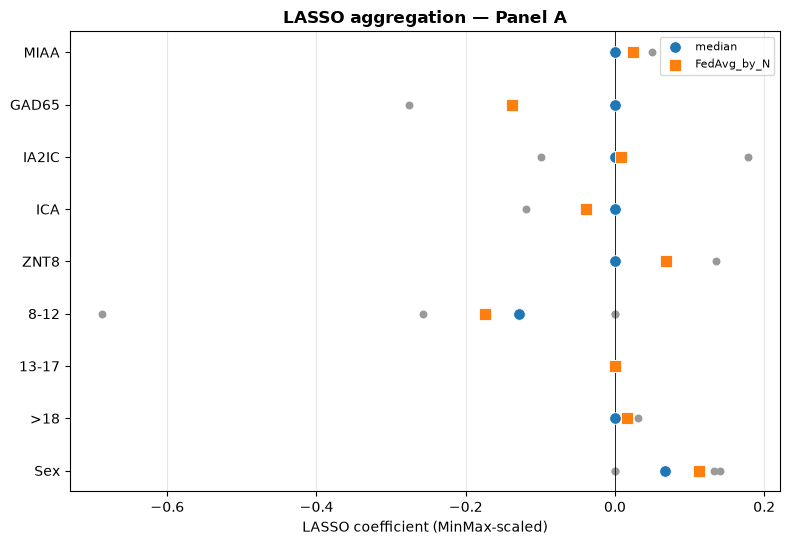

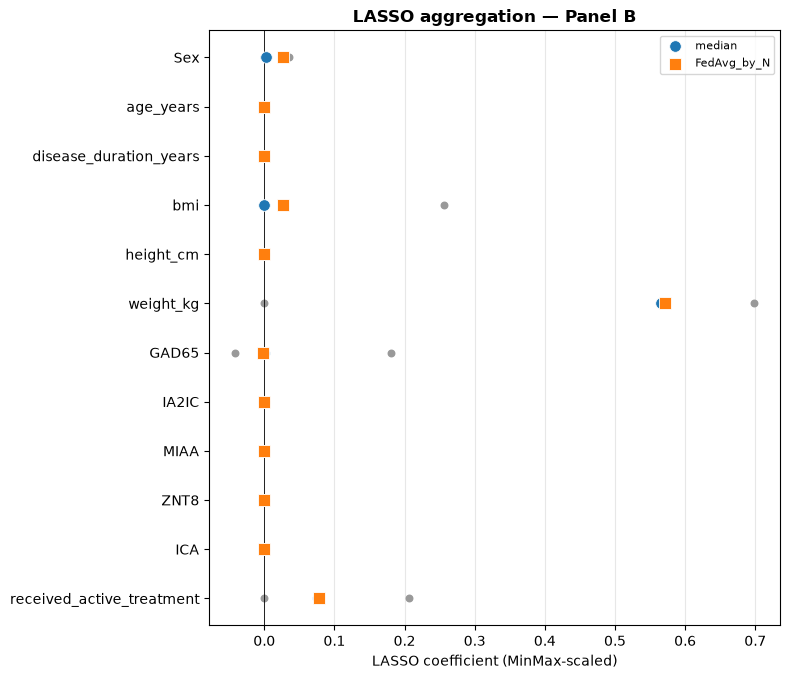

In [6]:
# Consensus coefficient comparison (per panel)
def plot_consensus(tbl, feats, names, panel):
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(feats) + 1.5))
    y = np.arange(len(feats))[::-1]
    for s in names:
        ax.scatter(tbl.loc[feats, s], y, s=22, color="0.6", zorder=2)
    for col, mk, c in [("median", "o", "#1f77b4"), ("FedAvg_by_N", "s", "#ff7f0e")]:
        ax.scatter(tbl.loc[feats, col], y, marker=mk, s=70, color=c,
                   edgecolor="white", linewidth=0.6, zorder=3, label=col)
    ax.axvline(0, color="k", lw=0.6); ax.set_yticks(y); ax.set_yticklabels(feats)
    ax.set_xlabel("LASSO coefficient (MinMax-scaled)")
    ax.set_title(f"LASSO aggregation — Panel {panel}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3); fig.tight_layout()
    fig.savefig(f"figures/federated_lasso_coef_panel{panel}.pdf", dpi=300)
    fig.savefig(f"figures/federated_lasso_coef_panel{panel}.png", dpi=220)
    plt.show()

plot_consensus(tblA, PANEL_A_FEATS, namesA, "A")
plot_consensus(tblB, PANEL_B_FEATS, namesB, "B")


## 6. Outputs

CSVs:
- `vectors/federated_lasso_panel{A,B}_consensus.csv` — per-study + median/IQR/
  FedAvg, plus how many sites selected each feature.
- `results/federated_lasso_performance.csv` — federated-CV MSE / R² / power per
  rule (Median, FedAvg, ADMM, Solo) for each cohort, incl. Panel B excl. SDY1737.

Figures:
- `federated_lasso_coef_panel{A,B}` — aggregation comparison.

The four features ADMM keeps on Panel B excluding SDY1737 — weight_kg, GAD65,
received_active_treatment, Sex — are carried into `PostLASSO_Federation.ipynb`,
which refits the methods on those four and shows SDY569 → SDY569 + SDY524.

Next analytical method: random forest (Union-of-Forests aggregation).
